In [1]:
from pathlib import Path
import pandas as pd

# Buscar la carpeta principal del proyecto
ROOT = Path.cwd()

while ROOT != ROOT.parent and not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

# Definir la ruta del archivo CSV
DATA_PATH = ROOT / "data" / "raw" / "Air_quality_data.csv"

print("Ruta del archivo:", DATA_PATH)
print("¿El archivo existe?:", DATA_PATH.exists())

# Extraer los datos desde el CSV
df = pd.read_csv(DATA_PATH)

# Mostrar el tamaño del dataset
print("Dimensiones del dataset:", df.shape)

# Mostrar las primeras filas
df.head()

Ruta del archivo: /workspaces/etl-calidad-aire-india/data/raw/Air_quality_data.csv
¿El archivo existe?: True
Dimensiones del dataset: (18265, 13)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor


In [2]:
# Información general del DataFrame
print("Información general del dataset:")
df.info()

# Detección de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Detección de filas duplicadas
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  str    
 1   Datetime    18265 non-null  str    
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  AQI         18265 non-null  float64
 12  AQI_Bucket  18265 non-null  str    
dtypes: float64(10), str(3)
memory usage: 1.8 MB

Valores nulos por columna:
City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
A

In [3]:
# Convertir la columna Datetime de texto a formato fecha
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

print("Tipo de dato de Datetime:")
print(df["Datetime"].dtype)

print("\nFecha mínima:")
print(df["Datetime"].min())

print("\nFecha máxima:")
print(df["Datetime"].max())

print("\nCantidad de fechas inválidas:")
print(df["Datetime"].isna().sum())

Tipo de dato de Datetime:
datetime64[us]

Fecha mínima:
2015-01-01 00:00:00

Fecha máxima:
2024-12-31 00:00:00

Cantidad de fechas inválidas:
0


In [4]:
# Crear nuevas variables temporales
df["Year"] = df["Datetime"].dt.year
df["Month"] = df["Datetime"].dt.month
df["Day"] = df["Datetime"].dt.day
df["Quarter"] = df["Datetime"].dt.quarter
df["Day_of_Week"] = df["Datetime"].dt.day_name()

# Mostrar las variables creadas
df[[
    "Datetime",
    "Year",
    "Month",
    "Day",
    "Quarter",
    "Day_of_Week"
]].head()

,Datetime,Year,Month,Day,Quarter,Day_of_Week
0,2015-01-01,2015,1,1,1,Thursday
1,2015-01-01,2015,1,1,1,Thursday
2,2015-01-01,2015,1,1,1,Thursday
3,2015-01-01,2015,1,1,1,Thursday
4,2015-01-01,2015,1,1,1,Thursday


In [5]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Datetime,18265,2020-01-01 00:00:00,2015-01-01 00:00:00,2017-07-02 00:00:00,2020-01-01 00:00:00,2022-07-02 00:00:00,2024-12-31 00:00:00,NaN
PM2.5,18265.0,250.597695,0.0,125.7,251.0,376.2,499.9,144.460292
PM10,18265.0,299.442491,0.0,150.1,300.3,450.0,600.0,173.479906
NO,18265.0,100.481035,0.0,50.6,100.2,151.0,200.0,57.774795
NO2,18265.0,75.415916,0.0,37.7,76.0,113.2,150.0,43.460066
NOx,18265.0,125.964079,0.0,63.1,126.2,188.9,250.0,72.403893
NH3,18265.0,25.065042,0.0,12.6,25.3,37.6,50.0,14.452019
CO,18265.0,5.002451,0.0,2.49,5.0,7.51,10.0,2.889439
SO2,18265.0,49.835839,0.0,24.4,49.9,75.1,100.0,28.988739
O3,18265.0,100.40674,0.0,50.6,100.7,150.4,200.0,57.591436


In [6]:
# Frecuencia de ciudades
print("Cantidad de registros por ciudad:")
print(df["City"].value_counts())

# Frecuencia de categorías de calidad del aire
print("\nCantidad de registros por categoría AQI:")
print(df["AQI_Bucket"].value_counts())

Cantidad de registros por ciudad:
City
Delhi        3653
Mumbai       3653
Chennai      3653
Kolkata      3653
Bangalore    3653
Name: count, dtype: int64

Cantidad de registros por categoría AQI:
AQI_Bucket
Very Poor       5501
Severe          5258
Moderate        4258
Poor            3129
Satisfactory     113
Good               6
Name: count, dtype: int64


In [7]:
# Variables numéricas que analizaremos
variables_numericas = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "AQI"
]

resultados_outliers = []

for columna in variables_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad_outliers = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ).sum()

    resultados_outliers.append({
        "Variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Cantidad de outliers": cantidad_outliers
    })

tabla_outliers = pd.DataFrame(resultados_outliers)

tabla_outliers

,Variable,Q1,Q3,Limite inferior,Limite superior,Cantidad de outliers
0,PM2.5,125.70,376.20,-250.05,751.95,0
1,PM10,150.10,450.00,-299.75,899.85,0
2,NO,50.60,151.00,-100.00,301.60,0
3,NO2,37.70,113.20,-75.55,226.45,0
4,NOx,63.10,188.90,-125.60,377.60,0
5,NH3,12.60,37.60,-24.90,75.10,0
6,CO,2.49,7.51,-5.04,15.04,0
7,SO2,24.40,75.10,-51.65,151.15,0
8,O3,50.60,150.40,-99.10,300.10,0
9,AQI,207.10,414.00,-103.25,724.35,0


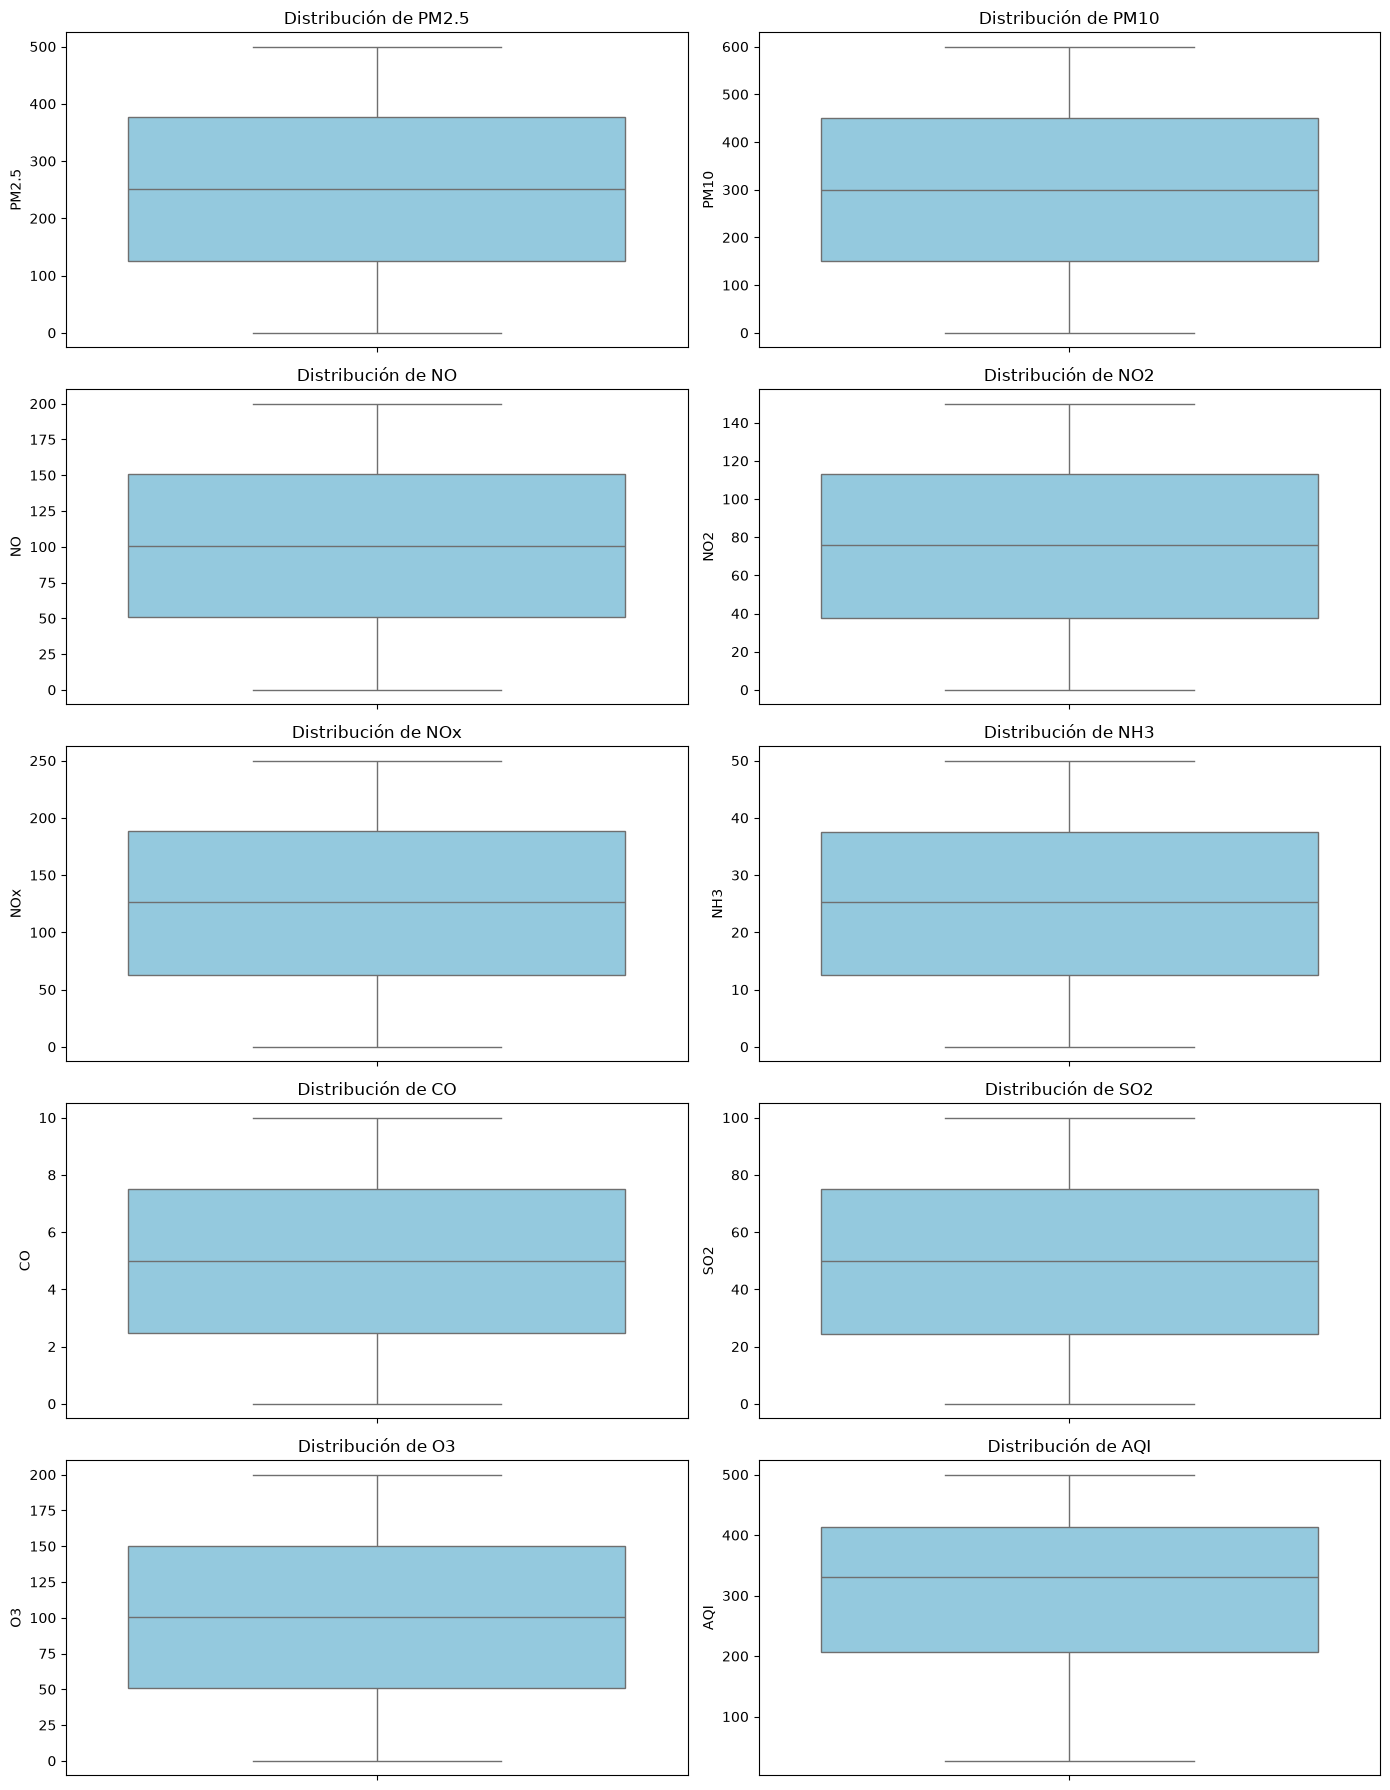

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráficos de caja para las variables numéricas
fig, axes = plt.subplots(5, 2, figsize=(14, 18))

for ax, columna in zip(axes.flat, variables_numericas):
    sns.boxplot(y=df[columna], ax=ax, color="skyblue")
    ax.set_title(f"Distribución de {columna}")
    ax.set_ylabel(columna)

plt.tight_layout()
plt.show()

In [ ]:
git add notebooks/01_exploracion_inicial.ipynb
git commit -m "feat: agrega visualizacion de distribuciones"
git push origin main